# makeshift — chemical shift re-referencing

BMRB deposited shifts are sometimes mis-referenced — the spectrometer reference frequency is off, which shifts all peaks of a given nucleus by a constant offset. This notebook demonstrates two correction methods:

- **PANAV** — probabilistic; assigns secondary structure from HA shifts and uses per-SS reference distributions (Wang & Wishart 2005)
- **LACS** — linear regression of secondary shifts against the CSI index; covers CA, CB, C′, N, and HN (Wang & Markley 2009)

Both methods return `(df, check, offsets)` so you can inspect what was corrected and by how much.

In [1]:
import makeshift as ms
import seaborn as sns
import matplotlib.pyplot as plt

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


## 1. Return values from `reref`

`ms.reref(df, method)` returns a 3-tuple:

| Name | Type | Description |
|---|---|---|
| `df` | DataFrame | Corrected shifts. Adds `orig` (pre-correction Val) plus method-specific flag columns (see below). |
| `check` | dict | `{atom: bool}` — True if re-referencing succeeded for that atom type. |
| `offsets` | dict | `{atom: float \| None}` — offset applied to each atom; None if fitting failed. |

**LACS-specific columns:**

| Column | Description |
|---|---|
| `orig` | Original Val before correction |
| `reref_mask` | True if shift was an inlier and was corrected; False if it was a statistical outlier or fitting failed |

**PANAV-specific columns:**

| Column | Description |
|---|---|
| `orig` | Original Val before correction |
| `outlier_1` | Outlier flag from round 1 |
| `outlier_2` | Outlier flag from round 2 |

## 2. PANAV re-referencing

PANAV assigns each residue to a secondary structure class (C/H/E) based on its HA chemical shift, then computes the offset needed to align observed shifts to that class's reference distribution. Two rounds of outlier rejection are applied.

In [2]:
# Fetch a well-structured protein
ms.fetch_nmrstar_file(4527)
entry = ms.parse_nmr_star('bmr4527_3.str')
cs = ms.get_chem_shifts(entry)

df_panav, check_panav, offsets_panav = ms.reref(cs, method='panav')

print('Offsets (ppm):', {k: f'{v:.4f}' if v is not None else None for k, v in offsets_panav.items()})
print('Converged:    ', check_panav)

Offsets (ppm): {'N': '-0.9947', 'CA': '0.1967', 'CB': '0.3330', 'C': None}
Converged:     {'N': True, 'CA': True, 'CB': True, 'C': False}


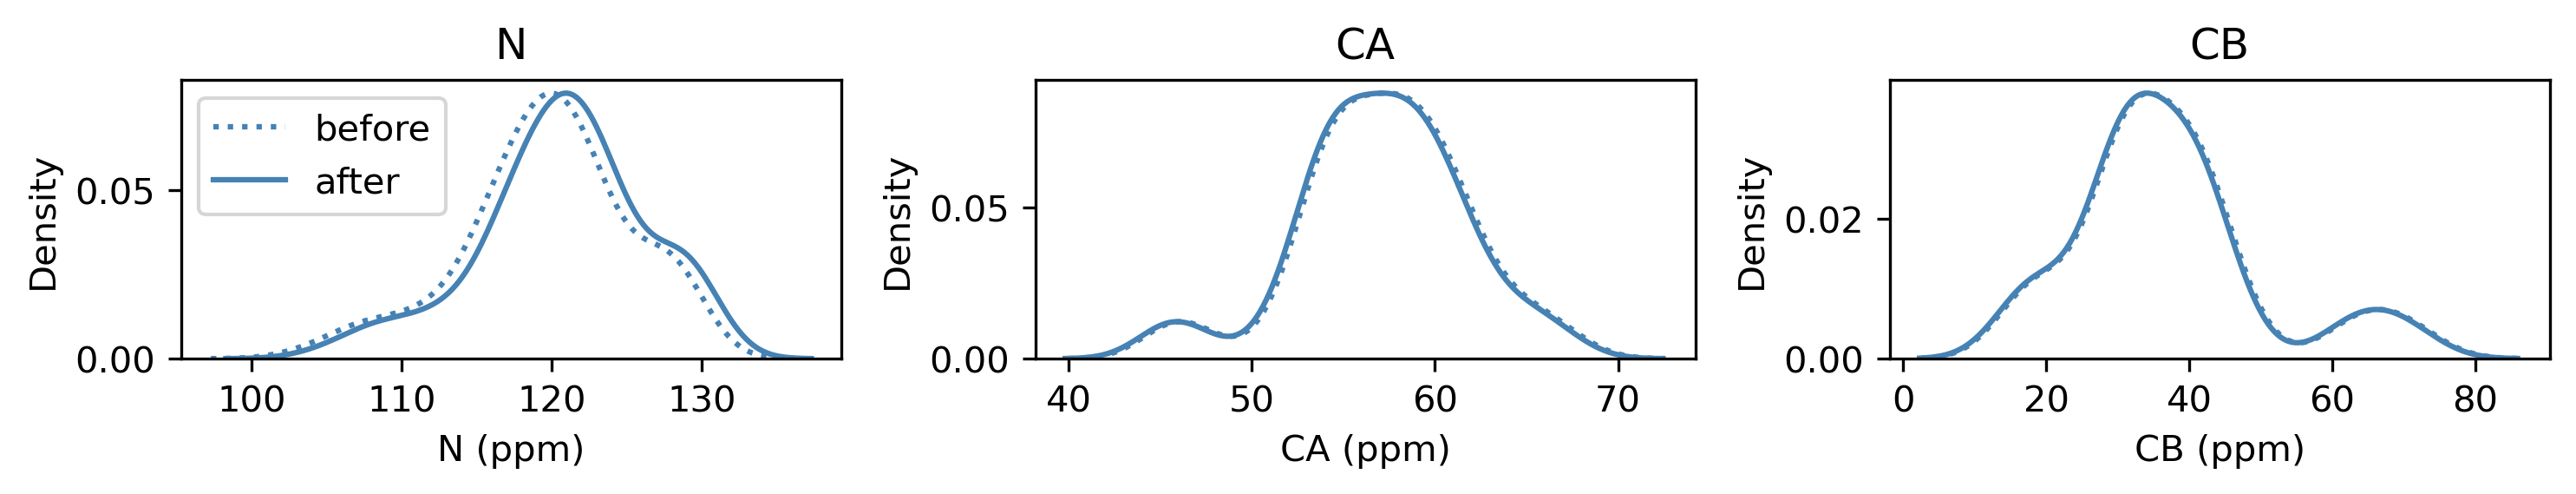

In [3]:
# Compare distributions before (dotted) and after (solid) correction
fig, axes = plt.subplots(1, 3, figsize=(10, 2))

for ax, atom_id in zip(axes, ['N', 'CA', 'CB']):
    sub = df_panav[df_panav['Atom_ID'] == atom_id]
    sns.kdeplot(sub['orig'], ax=ax, linestyle=':', color='steelblue', label='before')
    sns.kdeplot(sub['Val'],  ax=ax, color='steelblue', label='after')
    ax.set_xlabel(f'{atom_id} (ppm)')
    ax.set_title(atom_id)

axes[0].legend()
plt.tight_layout()

## 3. LACS re-referencing

LACS fits a linear model of secondary shift vs. CSI to determine the referencing offset for each atom type. It covers five atom types: CA, CB, C′, N, and HN. Shifts that fall outside `mean ± 4 std` of the BMRB full-database distribution are flagged as outliers (`reref_mask=False`) and excluded from the regression.

In [4]:
df_lacs, check_lacs, offsets_lacs = ms.reref(cs, method='lacs')

print('Offsets (ppm):', {k: f'{v:.4f}' if v is not None else None for k, v in offsets_lacs.items()})
print('Converged:    ', check_lacs)

Offsets (ppm): {'CA': '0.4028', 'CB': '0.4028', 'C': None, 'N': '1.0756', 'H': '0.1419'}
Converged:     {'CA': True, 'CB': True, 'C': False, 'N': True, 'H': True}


444/563 shifts used in regression (78.9%)


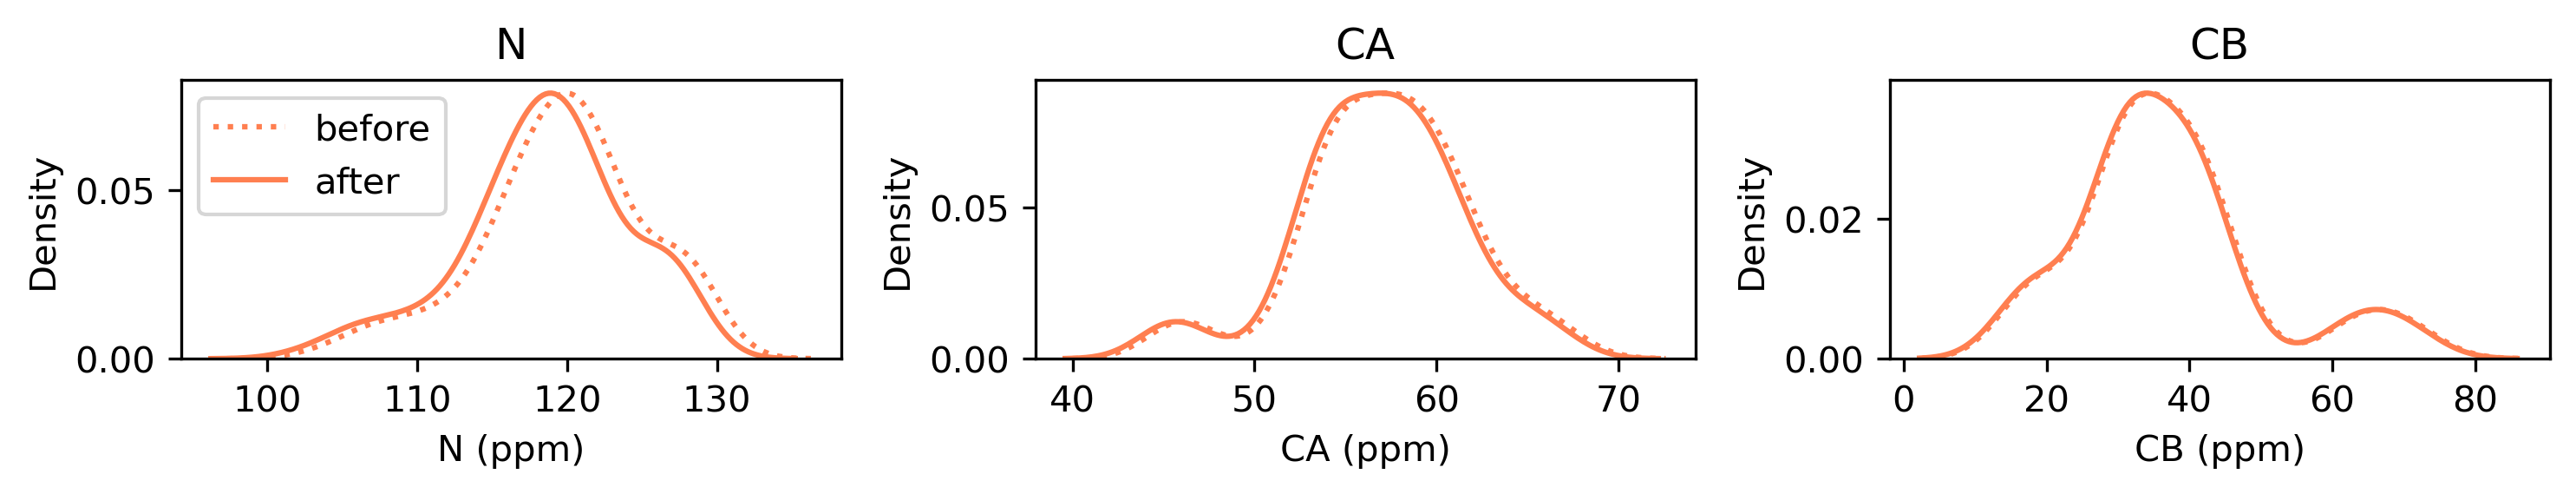

In [5]:
# reref_mask=False means the shift was excluded from fitting (outlier or atom type failed)
n_total   = len(df_lacs)
n_inliers = df_lacs['reref_mask'].sum()
print(f'{n_inliers}/{n_total} shifts used in regression ({100*n_inliers/n_total:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(10, 2))

for ax, atom_id in zip(axes, ['N', 'CA', 'CB']):
    sub = df_lacs[df_lacs['Atom_ID'] == atom_id]
    sns.kdeplot(sub['orig'], ax=ax, linestyle=':', color='coral', label='before')
    sns.kdeplot(sub['Val'],  ax=ax, color='coral', label='after')
    ax.set_xlabel(f'{atom_id} (ppm)')
    ax.set_title(atom_id)

axes[0].legend()
plt.tight_layout()

Note that for the above protein, PANAV and LACS give differing results.

## 4. Comparing both methods across multiple entries

Running both methods on a small set of proteins gives a sense of the magnitude of referencing errors and how the two approaches agree.

In [6]:
bmrb_ids = [4527, 6586, 4150]

results = []
for bmrb_id in bmrb_ids:
    ms.fetch_nmrstar_file(bmrb_id)
    entry = ms.parse_nmr_star(f'bmr{bmrb_id}_3.str')
    cs = ms.get_chem_shifts(entry)

    _, _, offsets_p = ms.reref(cs, method='panav')
    _, _, offsets_l = ms.reref(cs, method='lacs')

    for atom in ['N', 'CA', 'CB']:
        results.append({
            'bmrb_id': bmrb_id,
            'atom': atom,
            'panav': offsets_p.get(atom),
            'lacs':  offsets_l.get(atom),
        })

import pandas as pd
pd.DataFrame(results)

,bmrb_id,atom,panav,lacs
0,4527,N,-0.994706,1.075579
1,4527,CA,0.196726,0.402784
2,4527,CB,0.333000,0.402783
3,6586,N,-4.922000,-3.994060
4,6586,CA,-5.115310,-7.060243
5,6586,CB,NaN,-7.118230
6,4150,N,-1.088168,0.000000
7,4150,CA,-0.597423,-0.705335
8,4150,CB,NaN,-0.424287


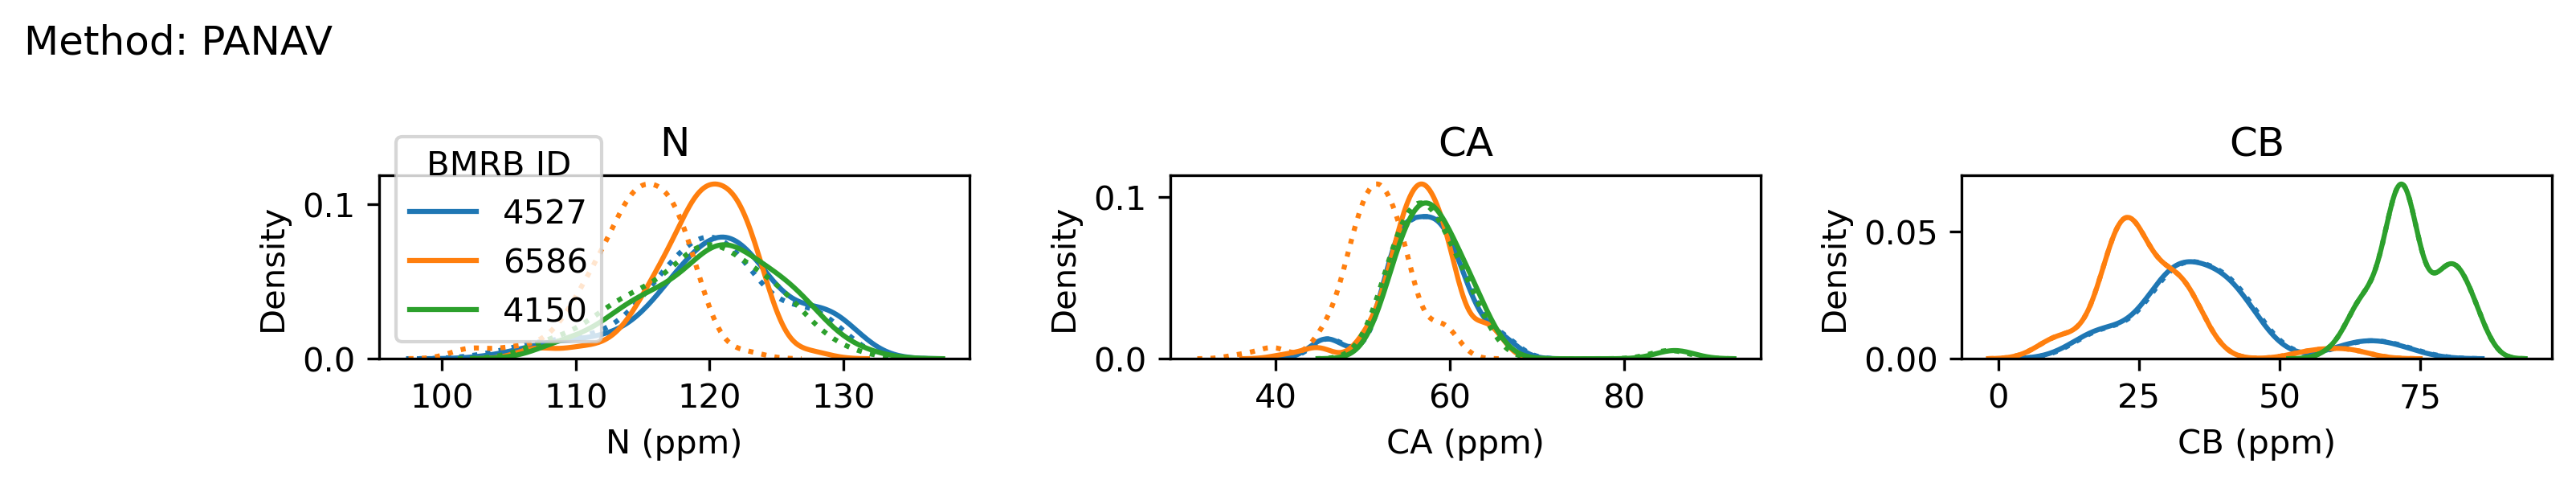

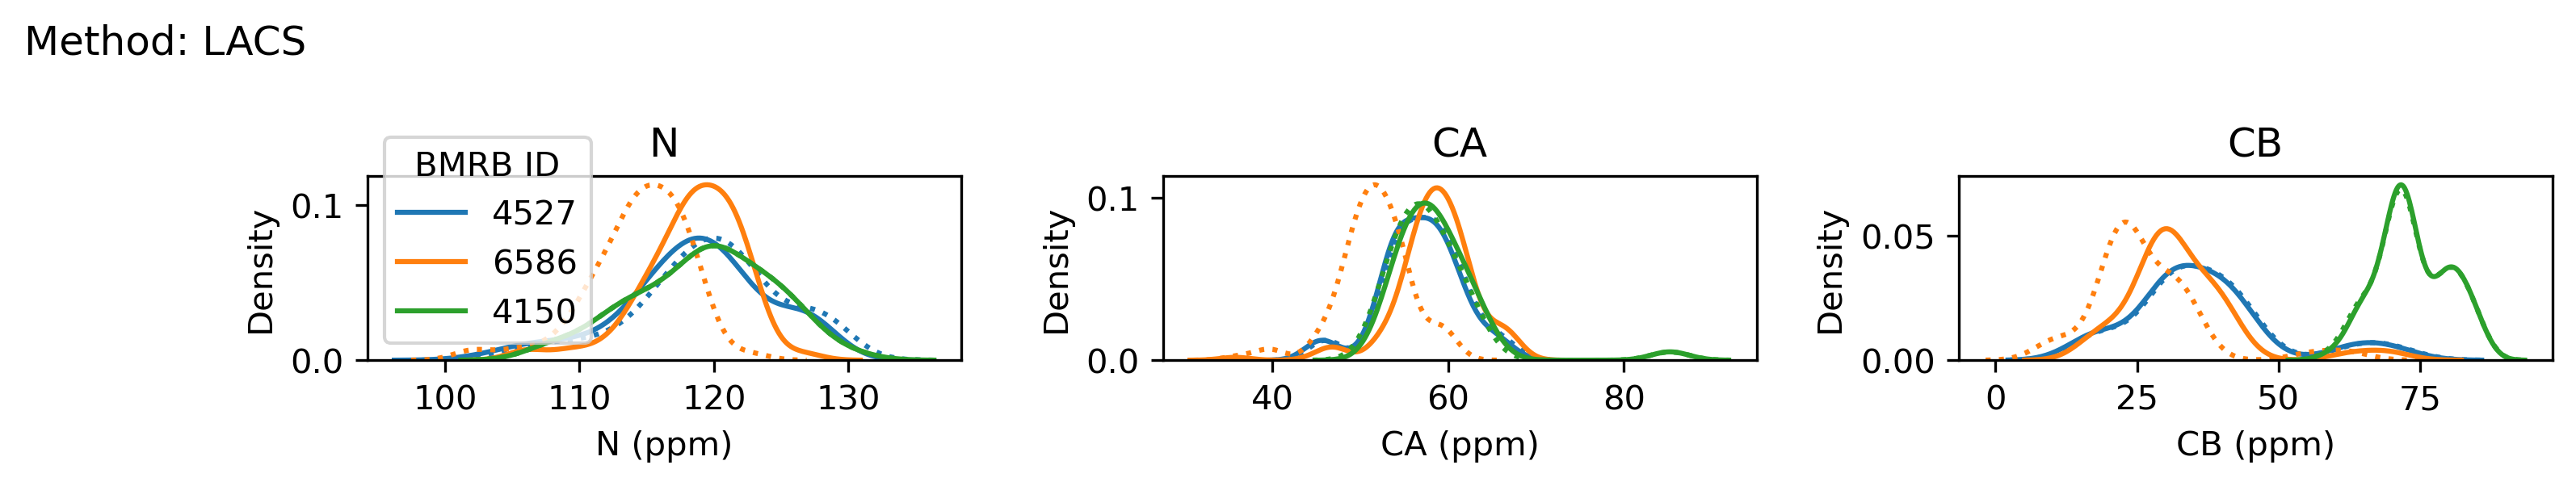

In [7]:
# Side-by-side KDE comparison for all three entries
colors = sns.color_palette()

for method in ('panav', 'lacs'):
    fig, axes = plt.subplots(1, 3, figsize=(10, 2))
    fig.suptitle(f'Method: {method.upper()}', x=0)

    for j, bmrb_id in enumerate(bmrb_ids):
        entry = ms.parse_nmr_star(f'bmr{bmrb_id}_3.str')
        cs = ms.get_chem_shifts(entry)
        df_r, _, _ = ms.reref(cs, method=method)

        for ax, atom_id in zip(axes, ['N', 'CA', 'CB']):
            sub = df_r[df_r['Atom_ID'] == atom_id]
            sns.kdeplot(sub['Val'],  ax=ax, color=colors[j], label=str(bmrb_id))
            sns.kdeplot(sub['orig'], ax=ax, color=colors[j], linestyle=':')
            ax.set_xlabel(f'{atom_id} (ppm)')
            ax.set_title(atom_id)

    axes[0].legend(title='BMRB ID')
    plt.tight_layout()
    plt.show()

## 5. Using corrected shifts downstream

The returned `df` contains corrected `Val` values and can be passed directly to any downstream analysis — CSI, HSQC simulation, etc.

Offsets: {'N': '-0.660', 'CA': '0.274', 'CB': '0.558', 'C': None}


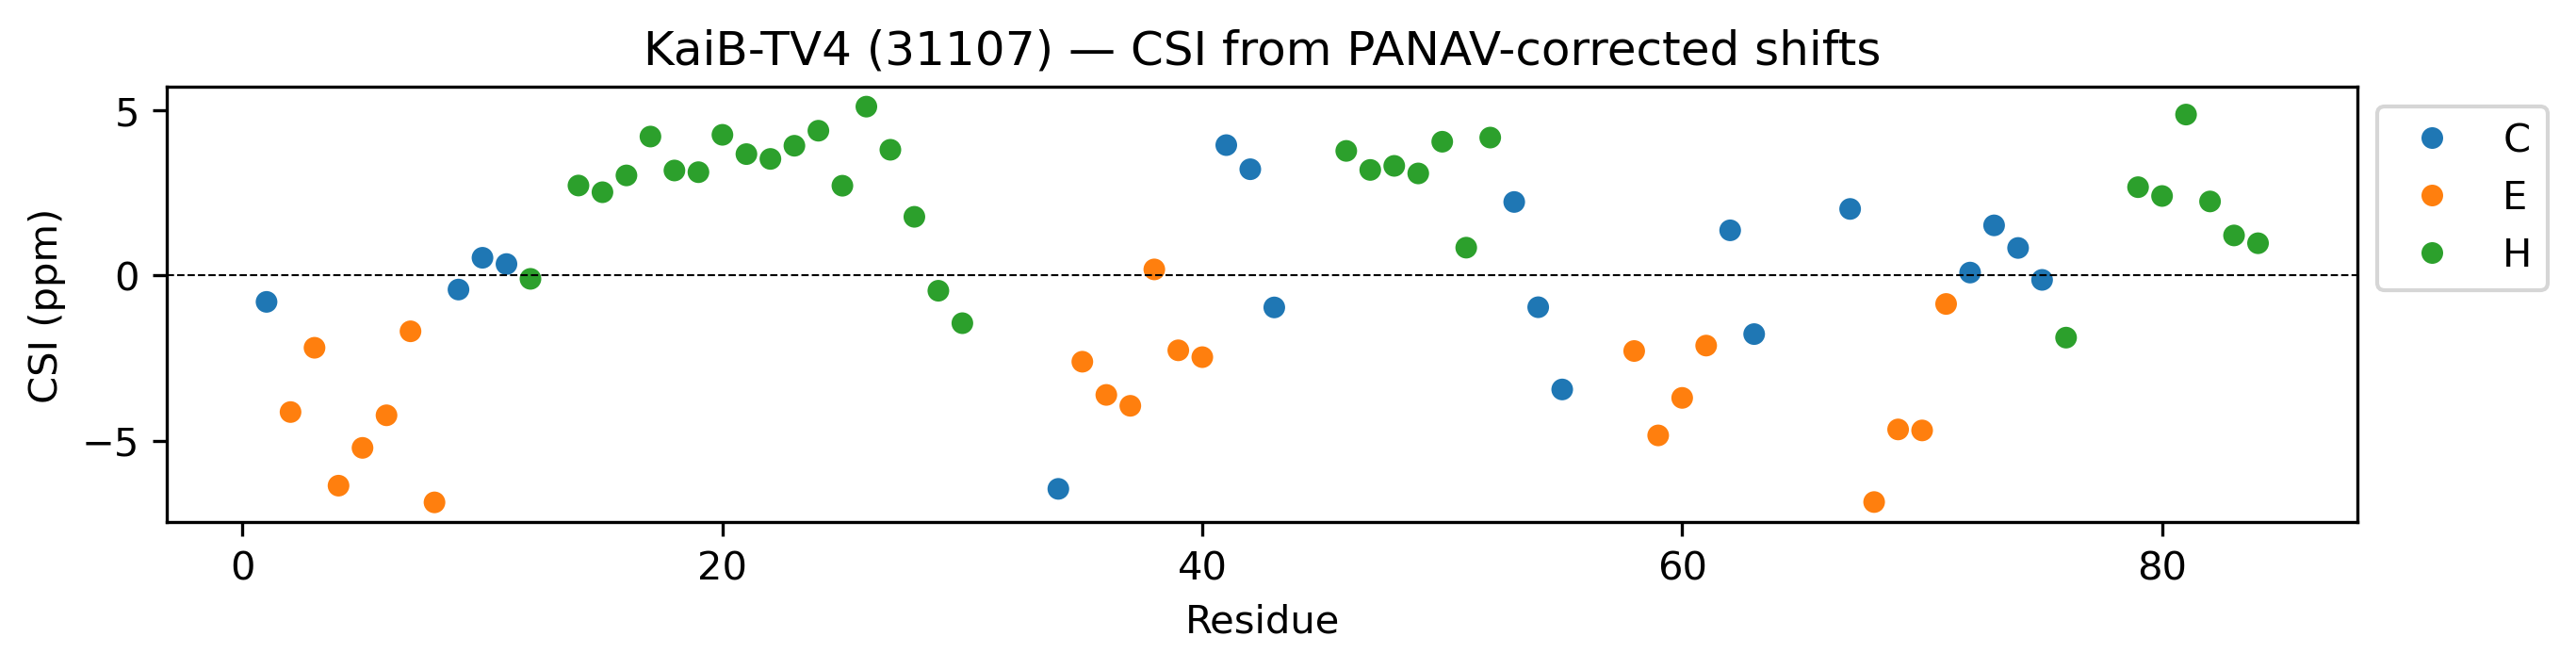

In [8]:
# KaiB-TV4: compute CSI from PANAV-corrected shifts
ms.fetch_nmrstar_file(31107)
entry = ms.parse_nmr_star('bmr31107_3.str')
cs = ms.get_chem_shifts(entry)

df_corr, check, offsets = ms.reref(cs, method='panav')
print('Offsets:', {k: f'{v:.3f}' if v is not None else None for k, v in offsets.items()})

# Re-compute CSI on corrected shifts
cs_corr = ms.get_chem_shifts(entry, calc_CSI=True)  # baseline (uncorrected)

seq = 'MYVFRLYVRGETHAAEVALKNLHDLLSSALKVPYTLKVVDVTKQPDLAEKDQVQATPTLVRVYPQPVRRLVGQLDHRYRLQHLLSP'
dss = 'CEEEEEEECCCHHHHHHHHHHHHHHHHHHHCCCCEEEEEECCCHHHHHHHHHCCCCCEEEECCCCCCEEEECCCCHHHHHHHHHHC'

tmp = cs_corr.loc[cs_corr.Atom_type == 'N'].copy()
tmp['dssp'] = tmp.apply(lambda row: dss[row['Seq_ID'] - 1], axis=1)

plt.figure(figsize=(10, 2))
sns.scatterplot(x='Seq_ID', y='csi_raw', hue='dssp', data=tmp)
plt.axhline(0, color='k', linewidth=0.5, linestyle='--')
plt.xlabel('Residue')
plt.ylabel('CSI (ppm)')
plt.title('KaiB-TV4 (31107) — CSI from PANAV-corrected shifts')
plt.legend(bbox_to_anchor=(1, 1))